# Linear Regression

[[ -10.42983652   21.68425064   93.05632423  128.91474014    1.65731484
   -34.6026329   -70.31437352  -89.58531844  -98.46564163   32.70849525
   -40.03735389  -84.63446045  -97.75956983  101.0649737    51.45154108
   -16.59203035  -99.32278049   19.56013456   25.56829129  -40.876179
  -116.14606798  -82.18129856  -99.42351759  -41.15065424  113.11719747]
 [  12.47508125   11.65201123  -47.62188868  -21.8925829   -25.8448612
   -46.95125313 -114.50080477  -96.25747314 -138.354981      3.50705716
   -44.79750103  -41.49521315  -72.49461735   92.35183172   78.56756726
   -22.89313291  -89.763107     -8.25030695   -8.79835255  -23.45209114
   -56.76906345  -26.72237168  -97.69430387   13.81611278    8.71189399]
 [   7.69618811   24.72954661   43.78238349  -53.28252258  -69.14579412
   -57.07233456 -114.14917063 -105.40873945  -71.89255963   66.89346043
    46.64709731 -103.67042713 -116.53228583  100.16767376   51.73974069
    -2.40640497   -3.85965547  -17.30123979   -1.62292435  -39.35

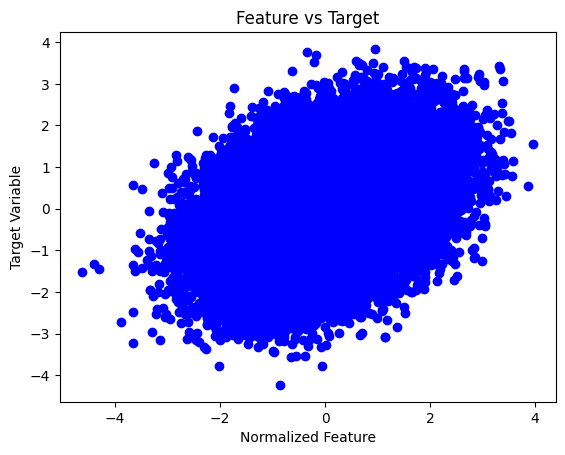

Iteration 0: Loss = 1.0000
Iteration 100: Loss = 0.8244
Iteration 200: Loss = 0.6805
Iteration 300: Loss = 0.5624
Iteration 400: Loss = 0.4657
Iteration 500: Loss = 0.3863
Iteration 600: Loss = 0.3213
Iteration 700: Loss = 0.2679
Iteration 800: Loss = 0.2242
Iteration 900: Loss = 0.1883
Iteration 1000: Loss = 0.1589
Iteration 1100: Loss = 0.1348
Iteration 1200: Loss = 0.1151
Iteration 1300: Loss = 0.0988
Iteration 1400: Loss = 0.0856
Iteration 1500: Loss = 0.0747
Iteration 1600: Loss = 0.0657
Iteration 1700: Loss = 0.0584
Iteration 1800: Loss = 0.0524
Iteration 1900: Loss = 0.0474
Iteration 2000: Loss = 0.0434
Iteration 2100: Loss = 0.0401
Iteration 2200: Loss = 0.0374
Iteration 2300: Loss = 0.0351
Iteration 2400: Loss = 0.0333
Iteration 2500: Loss = 0.0318
Iteration 2600: Loss = 0.0306
Iteration 2700: Loss = 0.0296
Iteration 2800: Loss = 0.0287
Iteration 2900: Loss = 0.0280
Iteration 3000: Loss = 0.0275
Iteration 3100: Loss = 0.0270
Iteration 3200: Loss = 0.0267
Iteration 3300: Loss =

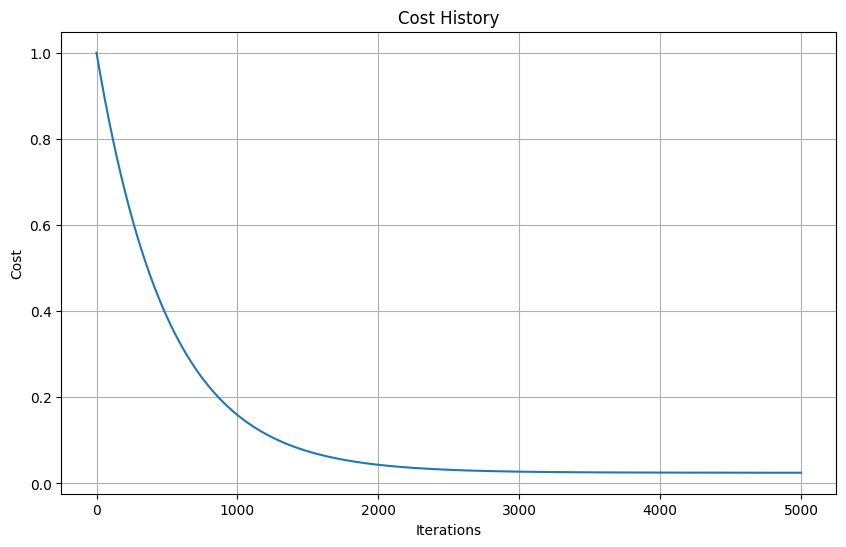

Training Metrics:
Mean Squared Error:  0.024998238690739413
Mean Absolute Error:  0.12653038990434753
R-squared:  0.9750017613092605


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def load_and_normalize_dataset(train_filepath):
    df = pd.read_csv(train_filepath)
    X = df.iloc[:, 1:-1].values
    y = df.iloc[:, -1].values
    print(X[:5,:])
    print(y[:5])
    X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    y_norm = (y - np.mean(y)) / np.std(y)
    return X_norm, y_norm

def plot_data(X, y):
    plt.scatter(X[:, 5], y, color='blue')
    plt.xlabel("Normalized Feature")
    plt.ylabel("Target Variable")
    plt.title("Feature vs Target")
    plt.show()

def compute_cost(y, y_pred):
    return np.mean((y_pred - y) ** 2)

def gradient_descent(X, y, alpha, iters):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    cost_history = []

    for i in range(iters):
        y_pred = np.dot(X, w) + b
        dw = (1 / m) * np.dot(X.T, (y_pred - y))
        db = (1 / m) * np.sum(y_pred - y)
        w -= alpha * dw
        b -= alpha * db
        loss = compute_cost(y, y_pred)
        cost_history.append(loss)
        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss:.4f}")

    return w, b, cost_history

def plot_cost_history(cost_history):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(cost_history)), cost_history)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost History")
    plt.grid(True)
    plt.show()

def evaluate_metrics(y, y_pred):
    mse = np.mean((y_pred - y) ** 2)
    mae = np.mean(np.abs(y_pred - y))
    ss_total = np.sum((y - np.mean(y)) ** 2)
    ss_residual = np.sum((y - y_pred) ** 2)
    r_squared = 1 - (ss_residual / ss_total)
    return mse, mae, r_squared

train_filepath = "/content/drive/MyDrive/Machine Learning Library /Datasets/linear_regression_train.csv"
X_train, y_train = load_and_normalize_dataset(train_filepath)
print(X_train.shape)
print(y_train.shape)
print(X_train[:5,:])
print(y_train[:5])
plot_data(X_train, y_train)
alpha = 0.001
iters = 5000
w, b, cost_history = gradient_descent(X_train, y_train, alpha, iters)
plot_cost_history(cost_history)
y_train_pred = np.dot(X_train, w) + b
train_mse, train_mae, train_r_squared = evaluate_metrics(y_train, y_train_pred)
print("Training Metrics:")
print("Mean Squared Error: ", train_mse)
print("Mean Absolute Error: ",train_mae)
print("R-squared: ", train_r_squared)


# Polynomial Regression

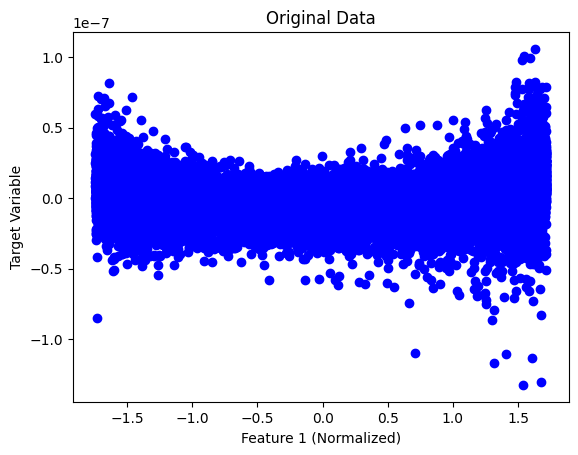

Epoch 0, Cost: 1.1358050686829174e-16
Epoch 100, Cost: 8.994651631256649e-17
Epoch 200, Cost: 8.715618425030055e-17
Epoch 300, Cost: 8.677967997710518e-17
Epoch 400, Cost: 8.672481824244955e-17
Epoch 500, Cost: 8.671432271449664e-17
Epoch 600, Cost: 8.671036219795136e-17
Epoch 700, Cost: 8.670768916565215e-17
Epoch 800, Cost: 8.670552375592571e-17
Epoch 900, Cost: 8.670370756824815e-17
Epoch 1000, Cost: 8.670217541045864e-17
Epoch 1100, Cost: 8.670088163556722e-17
Epoch 1200, Cost: 8.669978898451486e-17
Epoch 1300, Cost: 8.669886616742888e-17
Epoch 1400, Cost: 8.669808678253317e-17
Epoch 1500, Cost: 8.66974285352541e-17
Epoch 1600, Cost: 8.669687259688646e-17
Epoch 1700, Cost: 8.669640306545366e-17
Epoch 1800, Cost: 8.66960065107195e-17
Epoch 1900, Cost: 8.669567158997325e-17
Epoch 2000, Cost: 8.669538872354524e-17
Epoch 2100, Cost: 8.669514982076253e-17
Epoch 2200, Cost: 8.669494804850286e-17
Epoch 2300, Cost: 8.669477763572515e-17
Epoch 2400, Cost: 8.669463370838387e-17
Epoch 2500, C

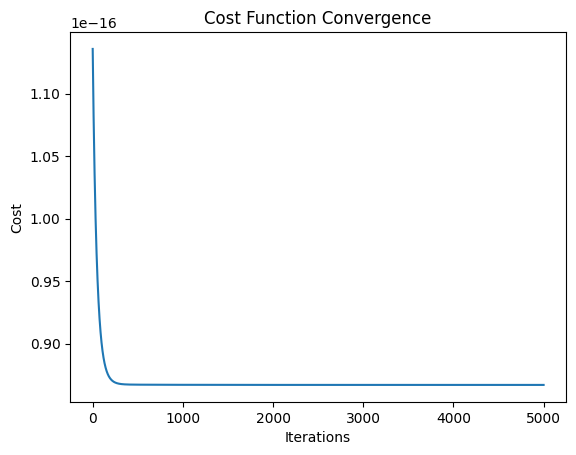

R-squared: 0.24012353709833534


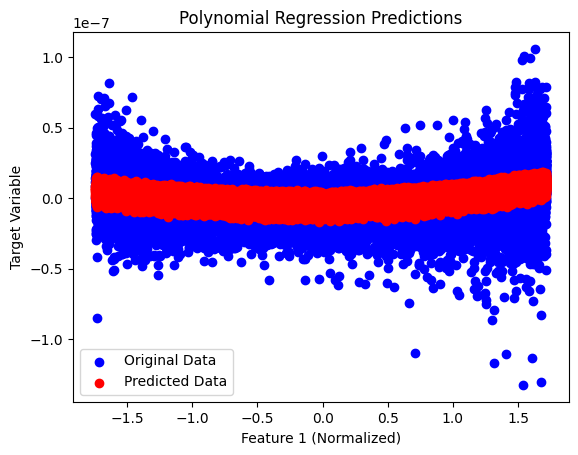

In [18]:
def expand_features(X, degree):
    m, n = X.shape
    X_poly = np.ones((m, 1))
    for d in range(1, degree + 1):
        for feature in range(n):
            X_poly = np.hstack((X_poly, (X[:, feature]**d).reshape(-1, 1)))
    mean = np.mean(X_poly, axis=0)
    std = np.std(X_poly, axis=0)
    std[std == 0] = 1e-8
    X_poly = (X_poly - mean) / std
    return X_poly

def predict(X_poly, w, b):
    return np.dot(X_poly, w) + b

def compute_cost(y, y_pred):
    return np.mean((y - y_pred)**2)

def gradient_descent(X_poly, y, w, b, alpha):
    m = len(y)
    y_pred = predict(X_poly, w, b)
    error = y_pred - y
    dW = (1 / m) * np.dot(X_poly.T, error)
    dB = (1 / m) * np.sum(error)
    w -= alpha * dW
    b -= alpha * dB
    return w, b

def train(X, y, degree, alpha, iters):
    X_poly = expand_features(X, degree)
    n = X_poly.shape[1]
    w = np.zeros(n)
    b = 0
    cost_history = []
    for i in range(iters):
        w, b = gradient_descent(X_poly, y, w, b, alpha)
        y_pred = predict(X_poly, w, b)
        cost = compute_cost(y, y_pred)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Epoch {i}, Cost: {cost}")
    plt.plot(range(iters), cost_history)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost Function Convergence")
    plt.show()
    return w, b

def evaluate(X, y, w, b, degree):
    X_poly = expand_features(X, degree)
    y_pred = predict(X_poly, w, b)
    mean_y = np.mean(y)
    ss_total = np.sum((y - mean_y)**2)
    ss_residual = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_residual / ss_total)
    return r_squared, y_pred

df = pd.read_csv("/content/drive/MyDrive/Machine Learning Library /Datasets/polynomial_regression_train.csv")
X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values
X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
plt.scatter(X_norm[:, 0], y, color='blue')
plt.xlabel("Feature 1 (Normalized)")
plt.ylabel("Target Variable")
plt.title("Original Data")
plt.show()

degree = 3
alpha = 0.01
iters = 5000
w, b = train(X_norm, y, degree, alpha, iters)
r2, y_pred = evaluate(X_norm, y, w, b, degree)
print(f"R-squared: {r2}")
plt.scatter(X_norm[:, 0], y, color='blue', label="Original Data")
plt.scatter(X_norm[:, 0], y_pred, color='red', label="Predicted Data")
plt.xlabel("Feature 1 (Normalized)")
plt.ylabel("Target Variable")
plt.title("Polynomial Regression Predictions")
plt.legend()
plt.show()


# Binary Classification

In [19]:
def load_dataset(train_filepath):
    df = pd.read_csv(train_filepath)
    X = df.iloc[:, 1:-1].values
    y = df.iloc[:, -1].values
    print(X[:5,:])
    print(y[:5])
    X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    return X_norm, y

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def compute_cost(y, y_pred):
  return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

def gradient_descent(X, y, alpha, iters):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    cost_history = []
    for i in range(iters):
        y_pred = sigmoid(np.dot(X, w) + b)
        dw = (1 / m) * np.dot(X.T, (y_pred - y))
        db = (1 / m) * np.sum(y_pred - y)
        w -= alpha * dw
        b -= alpha * db
        loss = compute_cost(y, y_pred)
        cost_history.append(loss)
        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss}")
    return w, b

def evaluate_metrics(y, y_pred):
    y_pred_binary=(y_pred >=0.5).astype(int)
    tp=np.sum((y_pred_binary == 1)&(y == 1))
    fp=np.sum((y_pred_binary == 1)&(y == 0))
    fn=np.sum((y_pred_binary == 0)&(y == 1))
    if(tp + fp)>0:
      precision=tp / (tp + fp)
    else:
      precision=0
    if(tp+fn)>0:
      recall=tp / (tp + fn)
    else:
      recall=0
    if(precision + recall)>0:
      f1_score = 2 * (precision * recall) / (precision + recall)
    else:
      f1_score=0
    return f1_score


train_filepath = "/content/drive/MyDrive/Machine Learning Library /Datasets/binary_classification_train.csv"
X_train, y_train = load_dataset(train_filepath)
alpha = 0.001
iters = 5000
w, b = gradient_descent(X_train, y_train, alpha, iters)
y_train_pred = sigmoid(np.dot(X_train, w) + b)
f1_score = evaluate_metrics(y_train, y_train_pred)
print(f"F1 score: {f1_score}")

[[ -36.96309934  -15.01470294   87.10043472  101.52335969   82.10657106
   -10.95617955    0.59232569  -51.91902789  -90.65043357   63.26021771
   -61.89333009  -81.18374446   13.10192062   18.05145032  -40.60628821
   -39.6970532   -13.87080222  173.72298705  -17.34916949  -82.55084389]
 [ -43.71567402   18.8471157    89.54340644  -71.31931362   35.59705183
   126.35856966  -29.83749503  -40.47376406  -94.0792385    -2.62338146
     6.32968473  -37.84826001    7.45735203  -77.4207421    53.7737182
  -100.12429376    9.87065041   11.59251925 -106.12360525  -92.79642051]
 [ -30.73755019  -63.72964268  106.08133168   81.77394826  112.76997552
   -12.42535146  -29.91328585  -41.77119961   16.42451066  -65.10591119
   -36.73741293 -106.61028904    5.93014282  -30.17708316 -138.96923366
   -56.05491444  -12.79066061  164.83249783  -37.41290151  -85.44115039]
 [ -27.67475726 -118.86949472  135.60521333   99.13018867   50.94754835
   -63.70478457   -7.35305697  -58.14022927  -80.20902729   81

# Multi-class Classification

[[ -90.53263395  -66.95347161   79.26185595 -111.80055375  126.40354931
   111.50934762  207.72895316  -26.60055598 -106.22932385  170.38464881
    69.03831992  148.39173402   77.83573824  -10.72820656    1.10062508
     1.0353615   -87.01080867  -16.24229669  -32.07492465  -17.66602617]
 [-103.15671956  -16.07040001   87.81922753   12.61459857   51.34778016
    67.48372459   40.26917154   51.44225374 -151.48669308   35.87250707
    28.01677435   29.00947498    3.9957856   -10.86162978 -142.60572601
   -25.92459239  -86.75535107  -36.47974913 -130.24661901  -44.14365222]
 [  24.32615256  -92.09807783   82.23835394  -56.79587877   85.20399558
   127.91650382  -90.08030677 -128.12407061   18.03602042   70.48507568
    56.46831797  111.81009848   65.82601808 -101.27120295  -44.12774943
    -7.13146423 -105.04975945 -130.94825564  -43.11352279  -37.33044832]
 [ -64.63173674  -83.70358275   84.13507175   -5.51615203   74.3384942
   112.63055562  181.57679783   -1.05402261   60.46986463   -0

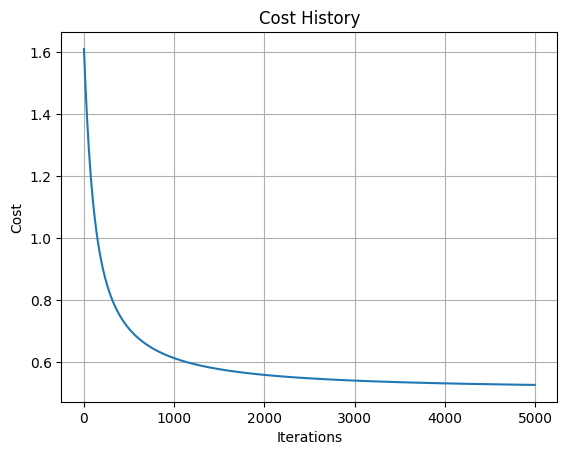

In [20]:
def load_and_normalize_train_dataset(train_filepath):
    df = pd.read_csv(train_filepath)
    X = df.iloc[:, 1:-1].values
    y = df.iloc[:, -1].values
    print(X[:5, :])
    print(y[:5])
    X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    return X_norm, y

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_cost(y, y_pred, m):
    log_likelihood = -np.log(y_pred[range(m), y])
    return np.sum(log_likelihood) / m

def gradient_descent(X, y, alpha, iters, n_classes):
    m, n = X.shape
    w = np.zeros((n, n_classes))
    b = np.zeros(n_classes)
    cost_history = []
    y_one_hot = np.zeros((m, n_classes))
    y_one_hot[np.arange(m), y] = 1

    for i in range(iters):
        logits = np.dot(X, w) + b
        y_pred = softmax(logits)
        dw = (1 / m) * np.dot(X.T, (y_pred - y_one_hot))
        db = (1 / m) * np.sum(y_pred - y_one_hot, axis=0)
        w -= alpha * dw
        b -= alpha * db
        cost = compute_cost(y, y_pred, m)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {cost:.4f}")
    return w, b, cost_history

def evaluate_metrics(X, y, w, b):
    logits=np.dot(X, w) + b
    y_pred=np.argmax(softmax(logits), axis=1)
    accuracy=np.mean(y_pred == y)
    n_classes=len(y)
    precision=[]
    recall=[]

    for c in range(n_classes):
        tp = np.sum((y_pred == c) & (y == c))
        fp = np.sum((y_pred == c) & (y != c))
        fn = np.sum((y_pred != c) & (y == c))
        if(tp+fp)>0:
          class_precision=tp/(tp+fp)
        else:
          class_precision=0
        if(tp+fn)>0:
          class_recall=tp/(tp+fn)
        else:
          class_recall=0
        precision.append(class_precision)
        recall.append(class_recall)
    f1_scores = []
    for i in range(n_classes):
        if precision[i] + recall[i] > 0:
            f1=2 * (precision[i] * recall[i]) / (precision[i] + recall[i])
        else:
            f1=0
        f1_scores.append(f1)
    class_weights = [np.sum(y == c) / len(y) for c in range(n_classes)]
    f1_score = np.sum([f1 * weight for f1, weight in zip(f1_scores, class_weights)])
    return accuracy, f1_score

train_filepath = "/content/drive/MyDrive/Machine Learning Library /Datasets/multi_classification_train.csv"
X_train, y_train = load_and_normalize_train_dataset(train_filepath)

n_classes = len(np.unique(y_train))
alpha = 0.01
iters = 5000
w, b, cost_history = gradient_descent(X_train, y_train, alpha, iters, n_classes)
accuracy, f1_score = evaluate_metrics(X_train, y_train, w, b)
print(f"Training Accuracy: {accuracy}")
print(f"Training F1 Score: {f1_score}")
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost History")
plt.grid()
plt.show()


# K-Means Clustering

(40000, 6)
[[-21.90459052 -22.65909077  12.80599532 -46.63193454 -34.34708058
  -21.98973763]
 [-28.6623852   68.7570811   31.76182149   3.98225896 -62.87686557
  -61.83856263]
 [-62.55120406  60.90923463   8.11291761  24.1100498  -64.37233589
   70.68194042]
 [ 14.4280236  -48.32604451 -65.5765179   76.02754907  69.96685159
   48.02395304]
 [  9.78028527 -55.64317211 -72.73729859  74.18012285  67.8733268
   41.12801501]]
[[-0.35139799 -0.37542604  0.54841073 -1.14716136 -0.24047117 -0.3996431 ]
 [-0.54362329  1.35051141  1.01882703  0.07881007 -0.84592181 -1.23656397]
 [-1.5075899   1.20234405  0.43194521  0.56634321 -0.87765824  1.54668434]
 [ 0.68208232 -0.86001817 -1.39676492  1.82388316  1.97324816  1.07081227]
 [ 0.54987751 -0.99816554 -1.57447007  1.77913501  1.92882     0.92598104]]
K-Means iteration 0/9
Iteration 0: Cost = 45800.9875
K-Means iteration 1/9
K-Means iteration 2/9
Iteration 2: Cost = 6388.0110
K-Means iteration 3/9
K-Means iteration 4/9
Iteration 4: Cost = 6388.01

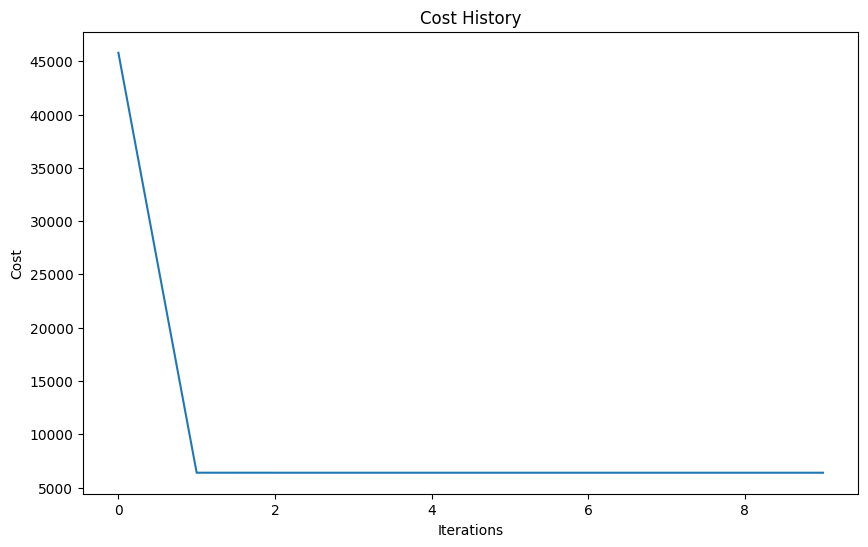

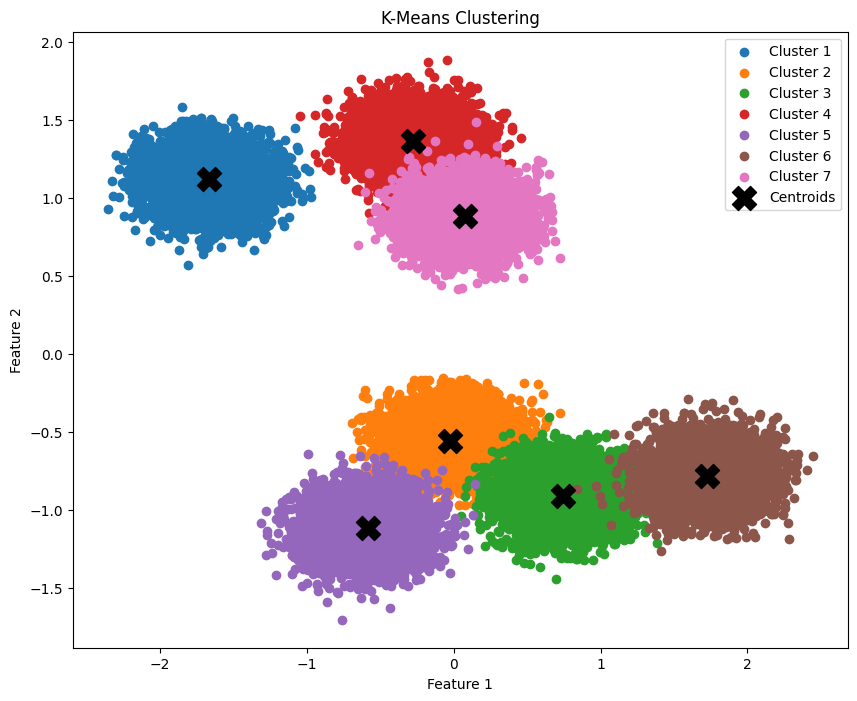

In [8]:
def find_closest_centroids(X, centroids):
    K=centroids.shape[0]
    m=X.shape[0]
    idx=np.zeros(X.shape[0],dtype=int)
    for i in range(m):
        distance=[]
        for j in range(K):
            distance.append(np.linalg.norm(X[i]-centroids[j]))
        idx[i]=np.argmin(distance)
    return idx

def compute_centroids(X, idx, K):
    m, n=X.shape
    centroids=np.zeros((K,n))
    for k in range(K):
        points=X[idx==k]
        centroids[k]=np.mean(points,axis=0)
    return centroids

def run_Kmeans(X, initial_centroids, iters):
    m, n=X.shape
    K=initial_centroids.shape[0]
    centroids=initial_centroids
    idx=np.zeros(m,dtype=int)
    cost_history=[]
    for i in range(iters):
        idx=find_closest_centroids(X, centroids)
        centroids=compute_centroids(X, idx, K)
        print("K-Means iteration %d/%d" % (i, iters-1))
        cost=compute_cost(X, idx, centroids)
        cost_history.append(cost)
        if i % 2 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
    return centroids, idx, cost_history

def compute_cost(X, idx, centroids):
    K=centroids.shape[0]
    m=X.shape[0]
    cost=0
    for k in range(K):
        points=X[idx==k]
        cost+=np.sum(np.linalg.norm(points-centroids[k],axis=1)**2)
    return cost

def Kmeans_init_centroids(X, K):
    np.random.seed(31)
    m=X.shape[0]
    randidx=np.random.permutation(m)
    centroids=X[randidx[:K]]
    return centroids

def plot_cost_history(cost_history):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(cost_history)), cost_history)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost History")
    plt.show()

def plot_clusters(X, idx, centroids):
    plt.figure(figsize=(10, 8))
    for k in range(centroids.shape[0]):
        cluster_points = X[idx == k]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {k+1}")
    plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("K-Means Clustering")
    plt.legend()
    plt.show()

df=pd.read_csv("/content/drive/MyDrive/Machine Learning Library /Datasets/unsupervised_data.csv")
X_train=df.iloc[:,1:].values
print(X_train.shape)
print(X_train[:5,:])
X_train_norm=(X_train-np.mean(X_train,axis=0))/np.std(X_train,axis=0)
print(X_train_norm[:5,:])
K=7
iters=10
initial_centroids=Kmeans_init_centroids(X_train_norm, K)
final_centroids, idx, cost_history=run_Kmeans(X_train_norm, initial_centroids, iters)
plot_cost_history(cost_history)
plot_clusters(X_train_norm, idx, final_centroids)

# K Nearest Neighbors

In [16]:
def euclidean_distance(a,b):
    sum=np.sum((a-b)**2)
    distance=np.sqrt(sum)
    return distance

def knn(X_train, y_train, x, k):
    distances=[euclidean_distance(x,x_train) for x_train in X_train]
    indices=np.argsort(distances)[:k]
    labels=[y_train[i] for i in indices]
    return labels

def predict(X_train, y_train, X, k):
    results=[]
    for x in X:
        k_nearest_labels=knn(X_train, y_train, x, k)
        pred=np.argmax(np.bincount(k_nearest_labels))
        results.append(pred)
    return np.array(results)

np.random.seed(42)
n_samples = 20
n_features = 5
k=3
features = np.random.uniform(0, 10, size=(n_samples, n_features))
labels = np.random.choice([0, 1], size=n_samples)
columns = [f"Feature_{i+1}" for i in range(n_features)] + ["Label"]
dataset = pd.DataFrame(np.column_stack((features, labels)), columns=columns)

X_train=dataset.iloc[:,:-1].values
y_train=dataset.iloc[:,-1].values
X = np.array([[2.420553,6.721355,7.616196,2.376375,7.282163], [0.368869,6.095643,5.026790,0.514788,2.786465], [9.624473,2.517823,4.972485,3.008783,2.848405], [9.082659,2.395619,1.448949,4.894528,9.856505]])
predictions = predict(X_train, y_train, X, k)
print(predictions)


[0 0 0 1]


# Decision Trees

In [ ]:
def entropy(y):
  entropy=0
  if len(y)!=0:
    p1=len(y[y==1])/len(y)
    if p1!=0 and p1!=1:
      entropy=-p1*np.log2(p1)-(1-p1)*np.log2(1-p1)
    else:
      entropy=0
  return entropy

def split(X, indices, feature):
  left_indices=[]
  right_indices=[]
  for i in indices:
    if X[i][feature]<=0.5:
      left_indices.append(i)
    else:
      right_indices.append(i)
  return left_indices, right_indices

def information_gain(X, y, indices, feature):
  left_indices, right_indices=split(X, indices, feature)
  X_node, y_node=X[indices], y[indices]
  X_left, y_left=X[left_indices], y[left_indices]
  X_right, y_right=X[right_indices], y[right_indices]
  entropy_node=entropy(y_node)
  entropy_left=entropy(y_left)
  entropy_right=entropy(y_right)
  w_left=len(X_left)/len(X_node)
  w_right=len(X_right)/len(X_node)
  ig=entropy_node-(w_left*entropy_left+w_right*entropy_right)
  return ig

def best_split(X, y, indices):
  n=X.shape[1]
  best_ig=-1
  best_feature=-1
  for feature in range(n):
    ig=information_gain(X, y, indices, feature)
    if ig>best_ig:
      best_ig=ig
      best_feature=feature
  return best_feature

def build_tree(X, y, indices, branch_name, max_depth, curr_depth):
  tree=[]
  if curr_depth == max_depth:
        formatting = " "*curr_depth + "-"*curr_depth
        print(formatting, "%s leaf node with indices" % branch_name, indices)
        return
  best_feature = best_split(X, y, indices)
  tree.append((curr_depth, branch_name, best_feature, indices))
  formatting = "-"*curr_depth
  print("%s Depth %d, %s: Split on feature: %d" % (formatting, curr_depth, branch_name, best_feature))
  left_indices, right_indices = split(X, indices, best_feature)
  build_tree(X, y, left_indices, "Left", max_depth, curr_depth+1)
  build_tree(X, y, right_indices, "Right", max_depth, curr_depth+1)

X_train = np.array([[1,1,1],[1,0,1],[1,0,0],[1,0,0],[1,1,1],[0,1,1],[0,0,0],[1,0,1],[0,1,0],[1,0,0]])
y_train = np.array([1,1,0,0,1,0,0,1,1,0])
indices = np.arange(len(y_train))
max_depth = 3
build_tree(X_train, y_train, indices, "Root", max_depth, 0)


 Depth 0, Root: Split on feature: 2
- Depth 1, Left: Split on feature: 1
-- Depth 2, Left: Split on feature: 0
   --- Left leaf node with indices [6]
   --- Right leaf node with indices [2, 3, 9]
-- Depth 2, Right: Split on feature: 0
   --- Left leaf node with indices [8]
   --- Right leaf node with indices []
- Depth 1, Right: Split on feature: 0
-- Depth 2, Left: Split on feature: 0
   --- Left leaf node with indices [5]
   --- Right leaf node with indices []
-- Depth 2, Right: Split on feature: 0
   --- Left leaf node with indices []
   --- Right leaf node with indices [0, 1, 4, 7]


# Neural Network

loss: 0.34496433801649234
loss: 0.34347014457409575
loss: 0.3419882156768759
loss: 0.34051889421569537
loss: 0.33906250704317026
loss: 0.33761936542689763
loss: 0.3361897655535149
loss: 0.33477398901919253
loss: 0.3333723032537327
loss: 0.3319849618442534
loss: 0.3306122047438793
loss: 0.32925425836557093
loss: 0.3279113355696744
loss: 0.32658363555836056
loss: 0.32527134369493615
loss: 0.3239746312736137
loss: 0.3226936552746581
loss: 0.32142855814647203
loss: 0.32017946765486655
loss: 0.3189464968280035
loss: 0.3177297440059032
loss: 0.31652929298309207
loss: 0.3153452132198682
loss: 0.31417756009634484
loss: 0.31302637519270254
loss: 0.3118916865930868
loss: 0.3107735092219197
loss: 0.3096718452244743
loss: 0.30858668439672393
loss: 0.3075180046555047
loss: 0.30646577252537227
loss: 0.3054299436109224
loss: 0.30441046302809227
loss: 0.30340726578456145
loss: 0.30242027712101227
loss: 0.30144941284196214
loss: 0.30049457966999404
loss: 0.29955567564958
loss: 0.2986325906112395
loss: 

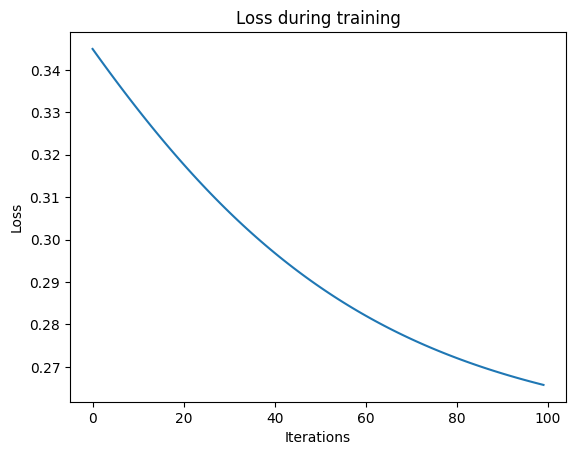

In [30]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def sigmoid_derivative(x):
    s=sigmoid(x)
    return s*(1 - s)

def forward_propagation(X, weights, biases, activation_func=sigmoid):
    activations=[X]
    for i in range(len(weights)):
        net=np.dot(activations[-1], weights[i]) + biases[i]
        activations.append(activation_func(net))
    return activations

def backward_propagation(X, y, weights, activations, activation_derivative=sigmoid_derivative):
    m=X.shape[0]
    delta=activations[-1] - y.reshape(-1, 1)
    dW=[]
    db=[]
    for i in range(len(weights) - 1, -1, -1):
        dW.insert(0, np.dot(activations[i].T, delta) / m)
        db.insert(0, np.sum(delta, axis=0, keepdims=True) / m)
        if i > 0:
            delta = np.dot(delta, weights[i].T) * activation_derivative(activations[i])
    return dW, db

def update_parameters(weights, biases, dW, db, learning_rate):
    for i in range(len(weights)):
        weights[i] -= learning_rate*dW[i]
        biases[i] -= learning_rate*db[i]
    return weights, biases

def compute_loss(y_true, y_pred):
    return np.mean((y_pred - y_true.reshape(-1, 1)) ** 2)

def fit(X, y, layers, iters, learning_rate, activation_func=sigmoid, activation_derivative=sigmoid_derivative):
    layer_sizes = [X.shape[1]] + layers
    weights=[]
    biases=[]
    for i in range(1, len(layer_sizes)):
        weights.append(np.random.randn(layer_sizes[i-1], layer_sizes[i]))
        biases.append(np.zeros((1, layer_sizes[i])))
    history = []

    for i in range(iters):
        activations=forward_propagation(X, weights, biases, activation_func)
        dW, db=backward_propagation(X, y, weights, activations, activation_derivative)
        weights, biases = update_parameters(weights, biases, dW, db, learning_rate)
        loss=compute_loss(y, activations[-1])
        print(f"loss: {loss}")
        history.append(loss)
    return weights, biases, history

def predict(X, weights, biases, activation_func=sigmoid):
    activations=forward_propagation(X, weights, biases, activation_func)
    predictions=activations[-1]
    return (predictions > 0.5).astype(int)

def evaluate_metrics(y_true, y_pred):
    tp=np.sum((y_true == 1)&(y_pred == 1))
    fp=np.sum((y_true == 0)&(y_pred == 1))
    fn=np.sum((y_true == 1)&(y_pred == 0))
    if (tp + fp)>0:
        precision=tp / (tp + fp)
    else:
        precision=0
    if (tp + fn)>0:
        recall=tp/(tp + fn)
    else:
      recall=0
    if (precision+recall)>0:
        f1_score=2*(precision * recall)/(precision + recall)
    else:
        f1_score=0
    return precision, recall, f1_score

df=pd.read_csv("/content/drive/MyDrive/Machine Learning Library /Datasets/nn_train.csv")
X=df.iloc[:,1:-2].values
y_train_binary=df.iloc[:,-2].values
y_train_class=df.iloc[:,-1].values
X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
layers = [16, 8, 1]
iters=100
learning_rate=0.01
weights, biases, history = fit(X_norm, y_train_binary, layers, iters, learning_rate)
y_pred = predict(X_norm, weights, biases)
precision, recall, f1_score = evaluate_metrics(y_train_binary, y_pred)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")
plt.plot(history)
plt.title("Loss during training")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()